<a href="https://colab.research.google.com/github/isha3456/Isha-/blob/main/homework22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Linear Regression MAE: 1.54
Logistic Regression Accuracy: 95.0 %

Enter New Patient Details
Age: 20
Disease Severity Score (1-10): 5
Treatment Hours: 4
Fitness Score (1-10): 5
Medicine Adherence (%): 90


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



------ Final Output ------
Recovery Days → -8
Status → Discharge


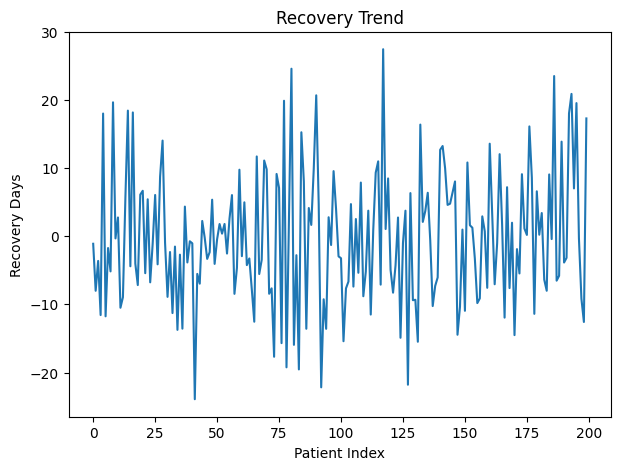

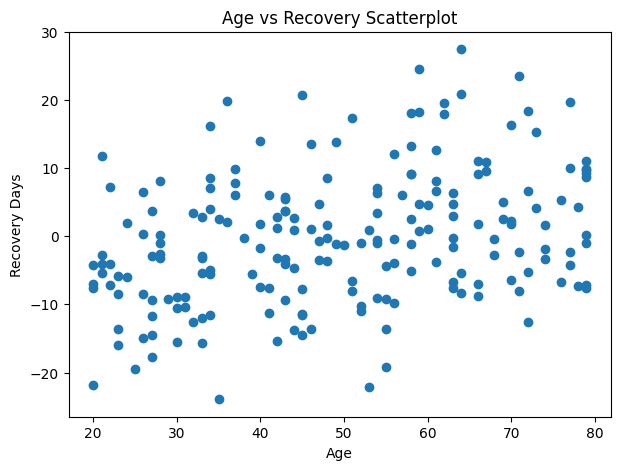

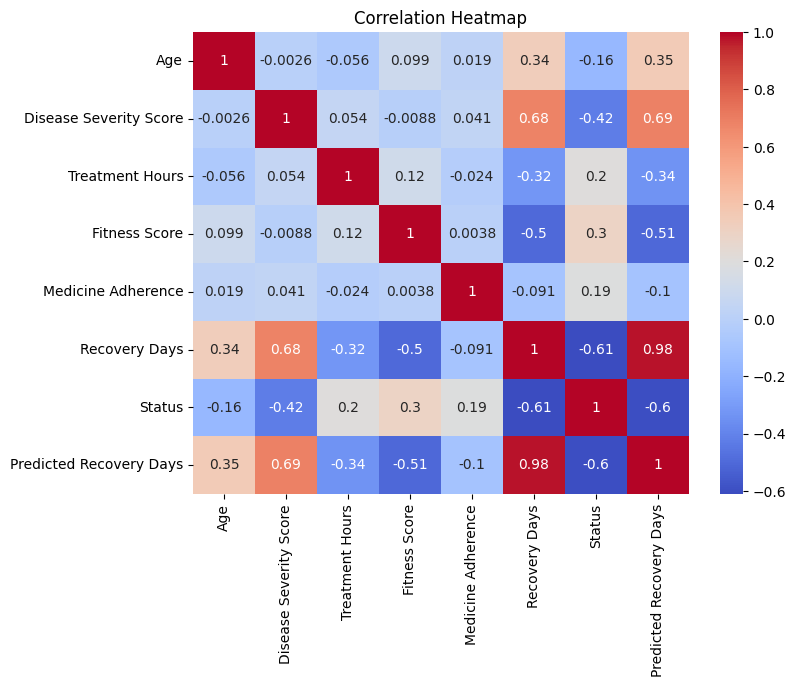

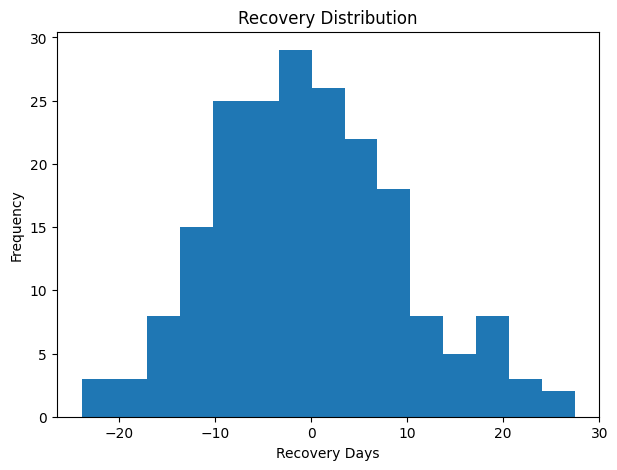

In [1]:
# 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score

np.random.seed(42)

n = 200

age = np.random.randint(20, 80, n)
severity = np.random.randint(1, 10, n)
treatment_hours = np.random.randint(1, 8, n)
fitness = np.random.randint(1, 10, n)
adherence = np.random.randint(50, 100, n)

recovery_days = (
    0.2 * age
    + 2.5 * severity
    - 1.5 * treatment_hours
    - 1.8 * fitness
    - 0.1 * adherence
    + np.random.normal(0, 2, n)
)

status = np.where(recovery_days <= 14, 1, 0)  # 1=Discharge, 0=Continue Treatment

df = pd.DataFrame({
    'Age': age,
    'Disease Severity Score': severity,
    'Treatment Hours': treatment_hours,
    'Fitness Score': fitness,
    'Medicine Adherence': adherence,
    'Recovery Days': recovery_days,
    'Status': status
})

X1 = df[['Age', 'Disease Severity Score', 'Treatment Hours',
         'Fitness Score', 'Medicine Adherence']]
y1 = df['Recovery Days']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X1_train, y1_train)

pred1 = lr.predict(X1_test)

print("Linear Regression MAE:", round(mean_absolute_error(y1_test, pred1), 2))

df['Predicted Recovery Days'] = lr.predict(X1)

X2 = df[['Age', 'Disease Severity Score', 'Treatment Hours',
         'Fitness Score', 'Medicine Adherence', 'Predicted Recovery Days']]
y2 = df['Status']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42)

log_model = LogisticRegression()
log_model.fit(X2_train, y2_train)

pred2 = log_model.predict(X2_test)

print("Logistic Regression Accuracy:",
      round(accuracy_score(y2_test, pred2) * 100, 2), "%")

print("\nEnter New Patient Details")

age = int(input("Age: "))
severity = int(input("Disease Severity Score (1-10): "))
treatment_hours = int(input("Treatment Hours: "))
fitness = int(input("Fitness Score (1-10): "))
adherence = int(input("Medicine Adherence (%): "))

new_patient = np.array([[age, severity, treatment_hours,
                         fitness, adherence]])

predicted_days = lr.predict(new_patient)[0]

new_patient2 = np.array([[age, severity, treatment_hours,
                          fitness, adherence, predicted_days]])

status_pred = log_model.predict(new_patient2)[0]

print("\n------ Final Output ------")
print("Recovery Days →", round(predicted_days))

if status_pred == 1:
    print("Status → Discharge")
else:
    print("Status → Continue Treatment")

plt.figure(figsize=(7,5))
plt.plot(df.index, df['Recovery Days'])
plt.xlabel("Patient Index")
plt.ylabel("Recovery Days")
plt.title("Recovery Trend")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(df['Age'], df['Recovery Days'])
plt.xlabel("Age")
plt.ylabel("Recovery Days")
plt.title("Age vs Recovery Scatterplot")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(7,5))
plt.hist(df['Recovery Days'], bins=15)
plt.xlabel("Recovery Days")
plt.ylabel("Frequency")
plt.title("Recovery Distribution")
plt.show()

Linear Regression MAE = 4232.92
Logistic Regression Accuracy = 92.5 %

Enter Employee Details
Experience (Years): 10
Performance Score (1-10): 9
Number of Certifications: 5
Working Hours per Day: 9
Skill Score (1-10): 8

------ Final Output ------
Salary → ₹ 104285.87
Promotion → Yes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


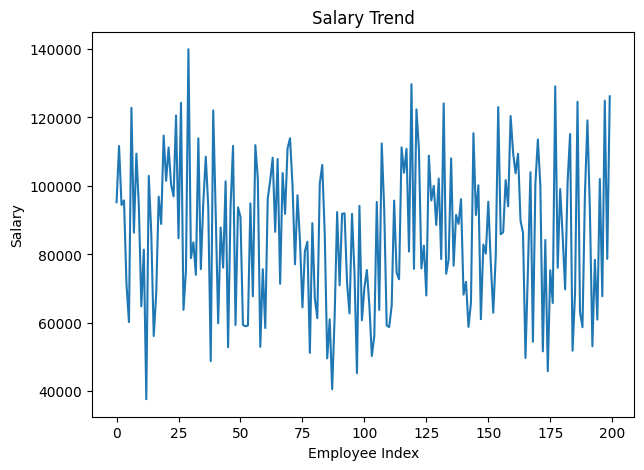

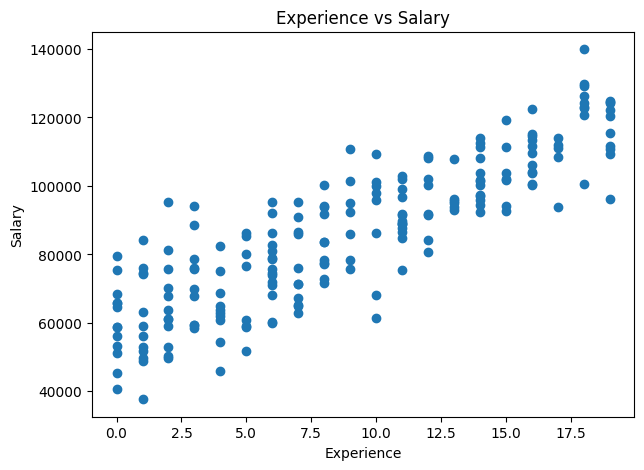

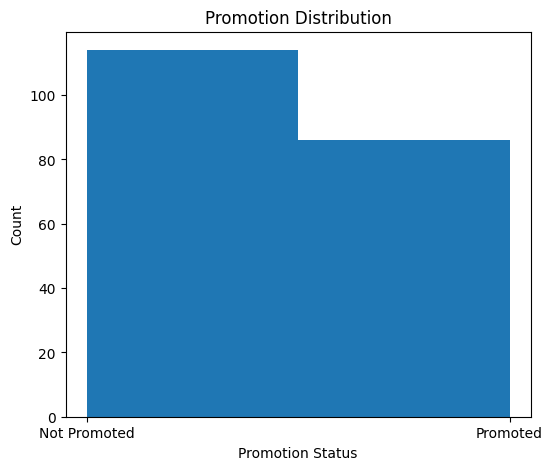

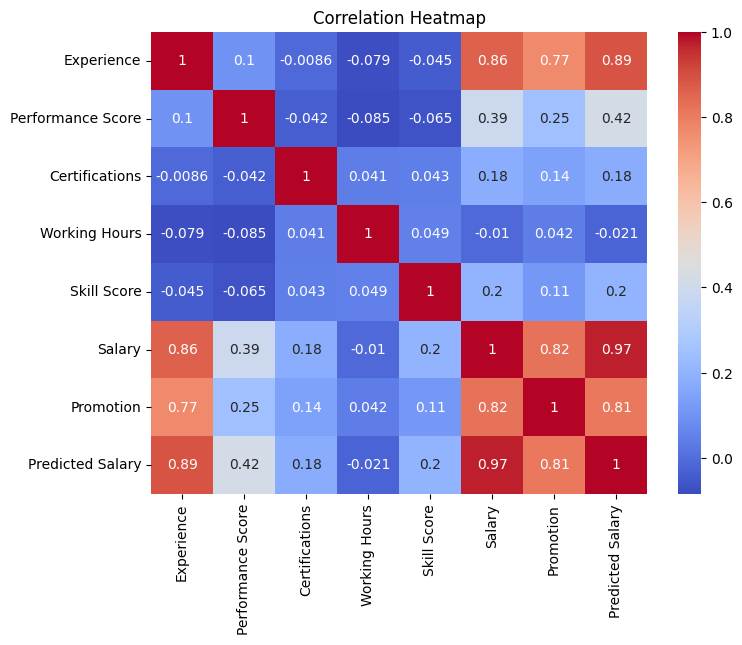

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score

np.random.seed(42)

n = 200

experience = np.random.randint(0, 20, n)
performance = np.random.randint(1, 11, n)
certifications = np.random.randint(0, 10, n)
working_hours = np.random.randint(6, 12, n)
skill_score = np.random.randint(1, 11, n)

salary = (
    20000
    + experience * 3000
    + performance * 2500
    + certifications * 1500
    + working_hours * 1000
    + skill_score * 2000
    + np.random.normal(0, 5000, n)
)

promotion = np.where(salary >= 92000, 1, 0)   # 1 = Promoted, 0 = Not Promoted

df = pd.DataFrame({
    "Experience": experience,
    "Performance Score": performance,
    "Certifications": certifications,
    "Working Hours": working_hours,
    "Skill Score": skill_score,
    "Salary": salary,
    "Promotion": promotion
})

X1 = df[["Experience", "Performance Score", "Certifications",
         "Working Hours", "Skill Score"]]
y1 = df["Salary"]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X1_train, y1_train)

y1_pred = lr_model.predict(X1_test)

print("Linear Regression MAE =", round(mean_absolute_error(y1_test, y1_pred), 2))

df["Predicted Salary"] = lr_model.predict(X1)

X2 = df[["Experience", "Performance Score", "Certifications",
         "Working Hours", "Skill Score", "Predicted Salary"]]
y2 = df["Promotion"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X2_train, y2_train)

y2_pred = log_model.predict(X2_test)

print("Logistic Regression Accuracy =",
      round(accuracy_score(y2_test, y2_pred) * 100, 2), "%")

print("\nEnter Employee Details")

exp = int(input("Experience (Years): "))
perf = int(input("Performance Score (1-10): "))
cert = int(input("Number of Certifications: "))
hours = int(input("Working Hours per Day: "))
skill = int(input("Skill Score (1-10): "))

new_data = np.array([[exp, perf, cert, hours, skill]])

predicted_salary = lr_model.predict(new_data)[0]

new_data2 = np.array([[exp, perf, cert, hours, skill, predicted_salary]])
promotion_pred = log_model.predict(new_data2)[0]

print("\n------ Final Output ------")
print("Salary → ₹", round(predicted_salary, 2))

if promotion_pred == 1:
    print("Promotion → Yes")
else:
    print("Promotion → No")

plt.figure(figsize=(7,5))
plt.plot(df.index, df["Salary"])
plt.xlabel("Employee Index")
plt.ylabel("Salary")
plt.title("Salary Trend")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(df["Experience"], df["Salary"])
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

plt.figure(figsize=(6,5))
plt.hist(df["Promotion"], bins=2)
plt.xticks([0,1], ["Not Promoted","Promoted"])
plt.xlabel("Promotion Status")
plt.ylabel("Count")
plt.title("Promotion Distribution")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Linear Regression MAE = 1.47
Logistic Regression Accuracy = 82.5 %

Enter New Student Details
Attendance (%): 80
Assignment Score: 3
Project Score: 4
Study Hours per Day: 7
Internal Marks: 90


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



------ Final Output ------
Predicted Percentage → 56.65 %
Scholarship → Not Eligible


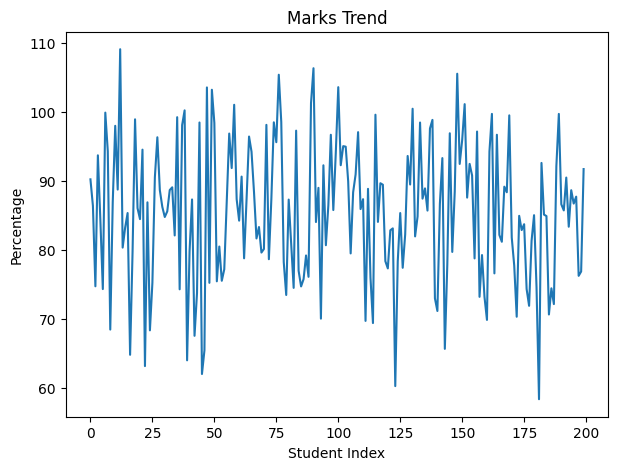

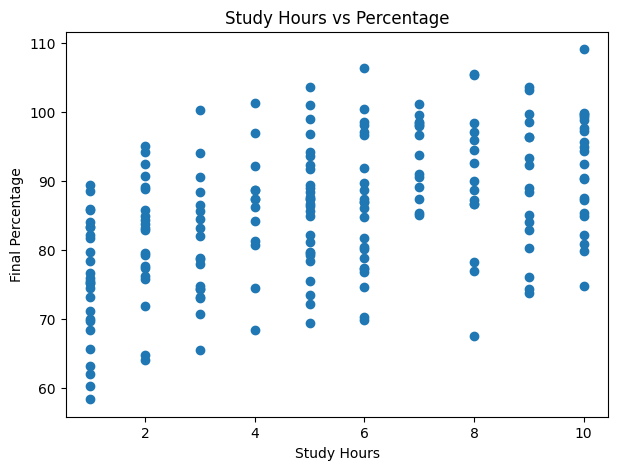

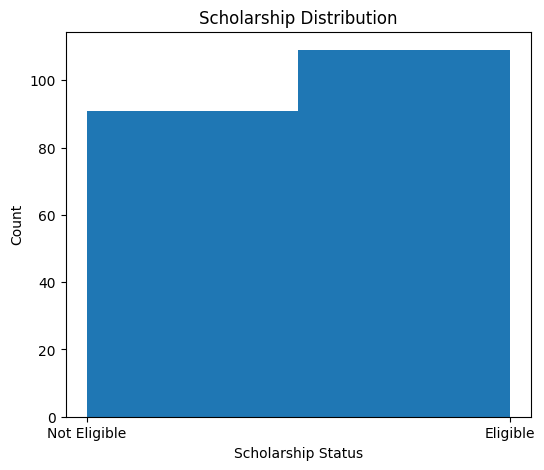

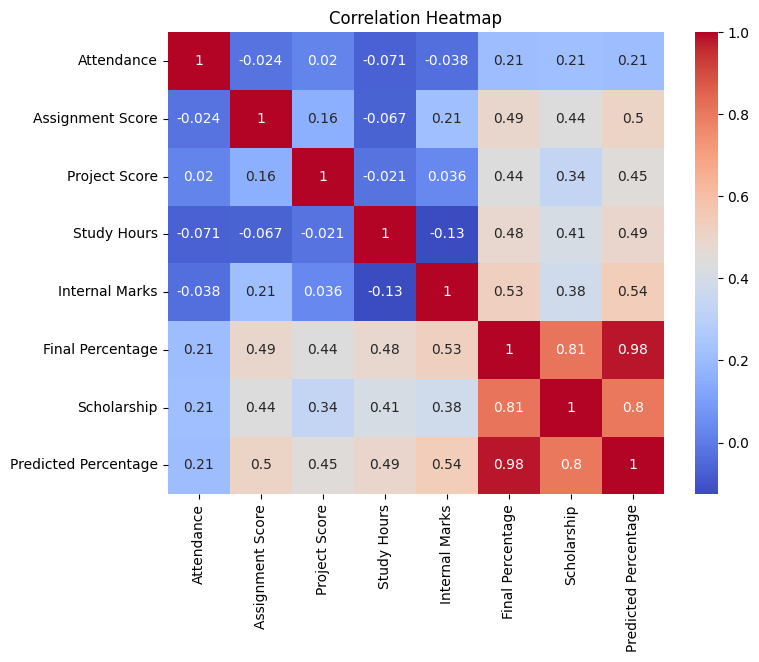

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score

np.random.seed(42)

n = 200

attendance = np.random.randint(60, 101, n)
assignment_score = np.random.randint(50, 101, n)
project_score = np.random.randint(50, 101, n)
study_hours = np.random.randint(1, 11, n)
internal_marks = np.random.randint(40, 101, n)

percentage = (
    0.20 * attendance
    + 0.25 * assignment_score
    + 0.25 * project_score
    + 2 * study_hours
    + 0.30 * internal_marks
    + np.random.normal(0, 2, n)
)

scholarship = np.where(percentage >= 85, 1, 0)   # 1 = Eligible, 0 = Not Eligible

df = pd.DataFrame({
    "Attendance": attendance,
    "Assignment Score": assignment_score,
    "Project Score": project_score,
    "Study Hours": study_hours,
    "Internal Marks": internal_marks,
    "Final Percentage": percentage,
    "Scholarship": scholarship
})

X1 = df[["Attendance", "Assignment Score", "Project Score",
         "Study Hours", "Internal Marks"]]
y1 = df["Final Percentage"]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X1_train, y1_train)

y1_pred = lr_model.predict(X1_test)

print("Linear Regression MAE =", round(mean_absolute_error(y1_test, y1_pred), 2))

df["Predicted Percentage"] = lr_model.predict(X1)

X2 = df[["Attendance", "Assignment Score", "Project Score",
         "Study Hours", "Internal Marks", "Predicted Percentage"]]
y2 = df["Scholarship"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X2_train, y2_train)

y2_pred = log_model.predict(X2_test)

print("Logistic Regression Accuracy =",
      round(accuracy_score(y2_test, y2_pred) * 100, 2), "%")

print("\nEnter New Student Details")

att = int(input("Attendance (%): "))
assign = int(input("Assignment Score: "))
project = int(input("Project Score: "))
hours = int(input("Study Hours per Day: "))
internal = int(input("Internal Marks: "))

new_student = np.array([[att, assign, project, hours, internal]])

# Predict Percentage
predicted_percentage = lr_model.predict(new_student)[0]

# Predict Scholarship
new_student2 = np.array([[att, assign, project, hours,
                          internal, predicted_percentage]])

scholarship_pred = log_model.predict(new_student2)[0]

print("\n------ Final Output ------")
print("Predicted Percentage →", round(predicted_percentage, 2), "%")

if scholarship_pred == 1:
    print("Scholarship → Eligible")
else:
    print("Scholarship → Not Eligible")

plt.figure(figsize=(7,5))
plt.plot(df.index, df["Final Percentage"])
plt.xlabel("Student Index")
plt.ylabel("Percentage")
plt.title("Marks Trend")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(df["Study Hours"], df["Final Percentage"])
plt.xlabel("Study Hours")
plt.ylabel("Final Percentage")
plt.title("Study Hours vs Percentage")
plt.show()

plt.figure(figsize=(6,5))
plt.hist(df["Scholarship"], bins=2)
plt.xticks([0,1], ["Not Eligible", "Eligible"])
plt.xlabel("Scholarship Status")
plt.ylabel("Count")
plt.title("Scholarship Distribution")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Linear Regression MAE = 86957.96
Logistic Regression Accuracy = 80.0 %

Enter Future Month Details
Advertisement Budget (₹): 300000
Customer Visits: 5000
Product Rating (1-5): 4.5
Number of Employees: 50
Customer Satisfaction (%): 90

------ Final Output ------
Revenue → ₹ 3255236.48
Business → Successful


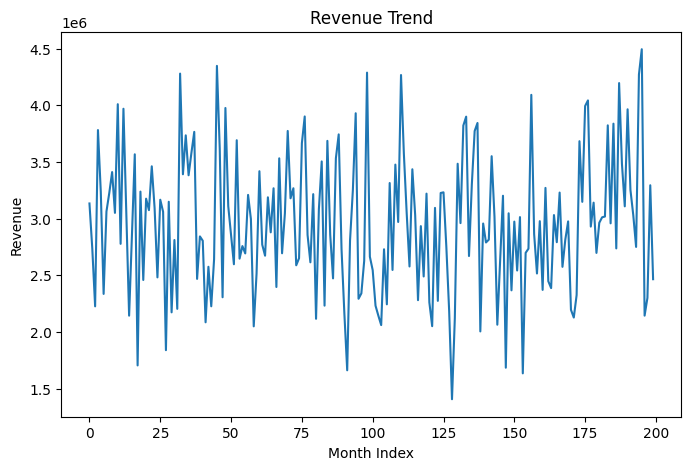

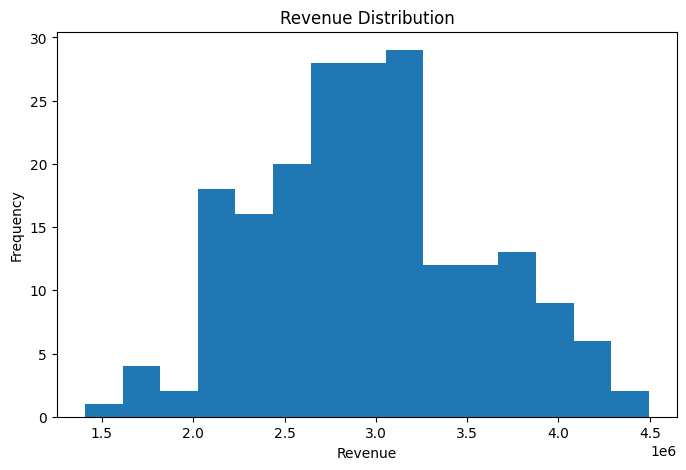

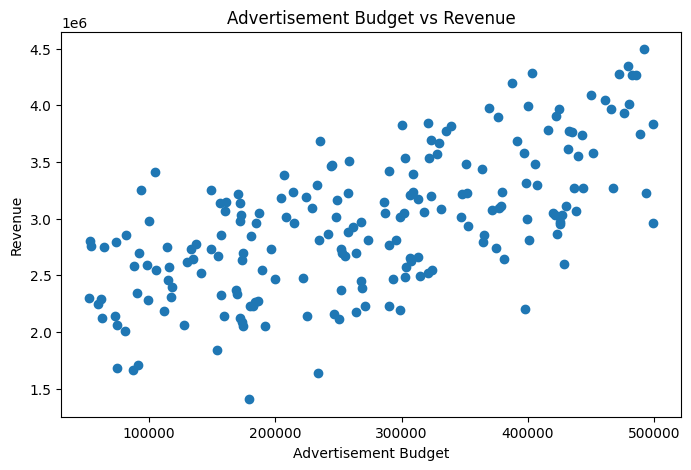

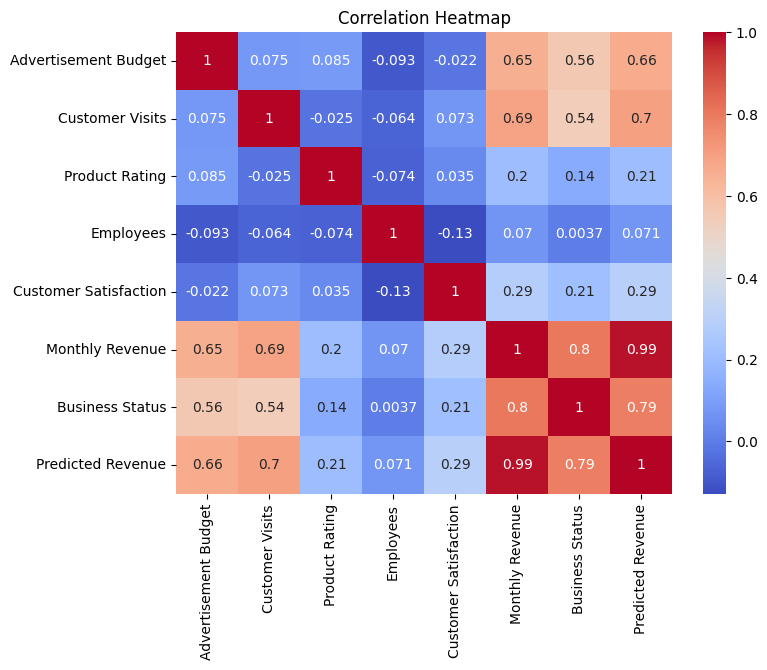

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score

# -----------------------------
# Create Dataset
# -----------------------------
np.random.seed(42)

n = 200

advertisement_budget = np.random.randint(50000, 500000, n)
customer_visits = np.random.randint(1000, 10000, n)
product_rating = np.random.uniform(1, 5, n)
employees = np.random.randint(10, 100, n)
customer_satisfaction = np.random.randint(50, 101, n)

# Monthly Revenue
monthly_revenue = (
    3 * advertisement_budget
    + 150 * customer_visits
    + 100000 * product_rating
    + 5000 * employees
    + 10000 * customer_satisfaction
    + np.random.normal(0, 100000, n)
)

# Create Business Status (0 and 1 both classes)
threshold = np.median(monthly_revenue)
business_status = np.where(monthly_revenue >= threshold, 1, 0)

# Create DataFrame
df = pd.DataFrame({
    "Advertisement Budget": advertisement_budget,
    "Customer Visits": customer_visits,
    "Product Rating": product_rating,
    "Employees": employees,
    "Customer Satisfaction": customer_satisfaction,
    "Monthly Revenue": monthly_revenue,
    "Business Status": business_status
})

# -----------------------------
# Model 1: Linear Regression
# -----------------------------
X1 = df[[
    "Advertisement Budget",
    "Customer Visits",
    "Product Rating",
    "Employees",
    "Customer Satisfaction"
]]

y1 = df["Monthly Revenue"]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X1_train, y1_train)

y1_pred = lr_model.predict(X1_test)

print("Linear Regression MAE =", round(mean_absolute_error(y1_test, y1_pred), 2))

# Predicted Revenue column
df["Predicted Revenue"] = lr_model.predict(X1)

# -----------------------------
# Model 2: Logistic Regression
# -----------------------------
X2 = df[[
    "Advertisement Budget",
    "Customer Visits",
    "Product Rating",
    "Employees",
    "Customer Satisfaction",
    "Predicted Revenue"
]]

y2 = df["Business Status"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X2_train, y2_train)

y2_pred = log_model.predict(X2_test)

print("Logistic Regression Accuracy =",
      round(accuracy_score(y2_test, y2_pred) * 100, 2), "%")

# -----------------------------
# User Input
# -----------------------------
print("\nEnter Future Month Details")

ad_budget = float(input("Advertisement Budget (₹): "))
visits = int(input("Customer Visits: "))
rating = float(input("Product Rating (1-5): "))
emp = int(input("Number of Employees: "))
satisfaction = int(input("Customer Satisfaction (%): "))

# Create DataFrame for Revenue Prediction
new_data = pd.DataFrame({
    "Advertisement Budget": [ad_budget],
    "Customer Visits": [visits],
    "Product Rating": [rating],
    "Employees": [emp],
    "Customer Satisfaction": [satisfaction]
})

# Predict Revenue
predicted_revenue = lr_model.predict(new_data)[0]

# Create DataFrame for Business Status Prediction
new_data2 = pd.DataFrame({
    "Advertisement Budget": [ad_budget],
    "Customer Visits": [visits],
    "Product Rating": [rating],
    "Employees": [emp],
    "Customer Satisfaction": [satisfaction],
    "Predicted Revenue": [predicted_revenue]
})

# Predict Business Status
status = log_model.predict(new_data2)[0]

# -----------------------------
# Final Output
# -----------------------------
print("\n------ Final Output ------")
print("Revenue → ₹", round(predicted_revenue, 2))

if status == 1:
    print("Business → Successful")
else:
    print("Business → Business Risk")

# -----------------------------
# Graph 1: Revenue Trend
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(df.index, df["Monthly Revenue"])
plt.xlabel("Month Index")
plt.ylabel("Revenue")
plt.title("Revenue Trend")
plt.show()

# -----------------------------
# Graph 2: Revenue Distribution
# -----------------------------
plt.figure(figsize=(8, 5))
plt.hist(df["Monthly Revenue"], bins=15)
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.title("Revenue Distribution")
plt.show()

# -----------------------------
# Graph 3: Advertisement vs Revenue
# -----------------------------
plt.figure(figsize=(8, 5))
plt.scatter(df["Advertisement Budget"], df["Monthly Revenue"])
plt.xlabel("Advertisement Budget")
plt.ylabel("Revenue")
plt.title("Advertisement Budget vs Revenue")
plt.show()

# -----------------------------
# Graph 4: Correlation Heatmap
# -----------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Linear Regression MAE = 1.5
Logistic Regression Accuracy = 90.0 %

Enter Student Details
Attendance (%): 90
Assignment Marks: 88
Quiz Marks: 95
Project Marks: 85
Communication Score: 90

------ Final Output ------
Internship Score → 88.38
Placement → Placed


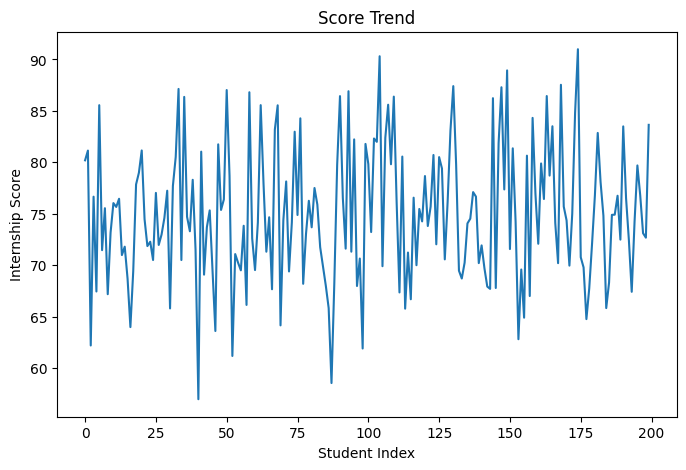

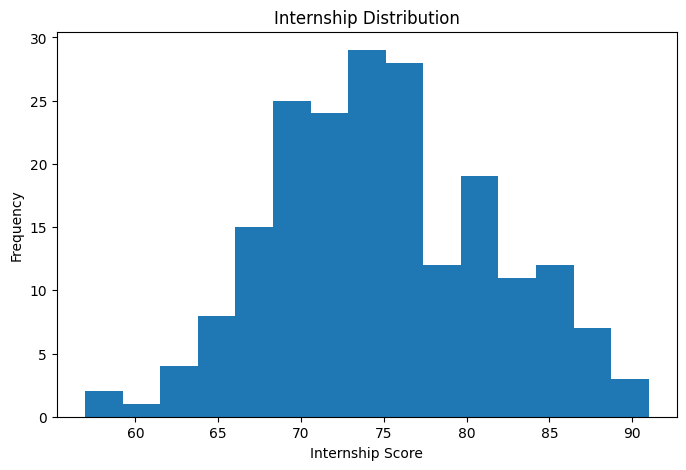

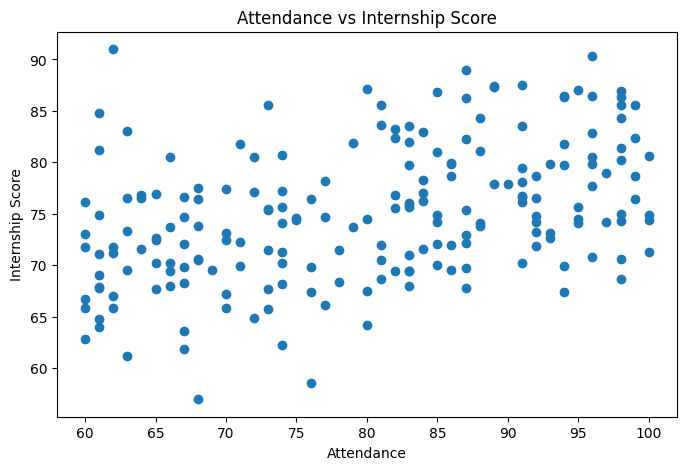

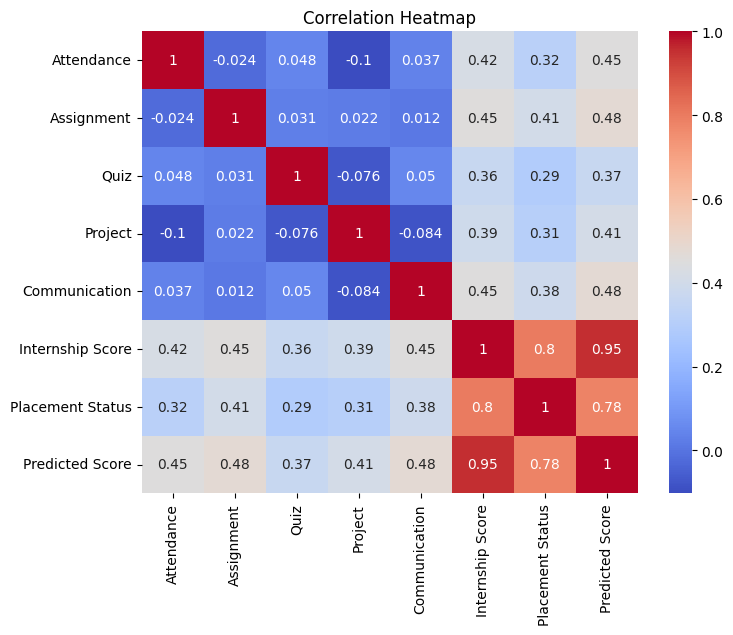

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score

np.random.seed(42)

n = 200

attendance = np.random.randint(60, 101, n)
assignment = np.random.randint(50, 101, n)
quiz = np.random.randint(40, 101, n)
project = np.random.randint(50, 101, n)
communication = np.random.randint(40, 101, n)

# Final Internship Score
internship_score = (
    0.25 * attendance
    + 0.20 * assignment
    + 0.15 * quiz
    + 0.25 * project
    + 0.15 * communication
    + np.random.normal(0, 2, n)
)

# Placement Status (0 = Not Placed, 1 = Placed)
threshold = np.median(internship_score)
placement_status = np.where(internship_score >= threshold, 1, 0)

# DataFrame
df = pd.DataFrame({
    "Attendance": attendance,
    "Assignment": assignment,
    "Quiz": quiz,
    "Project": project,
    "Communication": communication,
    "Internship Score": internship_score,
    "Placement Status": placement_status
})

X1 = df[[
    "Attendance",
    "Assignment",
    "Quiz",
    "Project",
    "Communication"
]]

y1 = df["Internship Score"]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X1_train, y1_train)

y1_pred = lr_model.predict(X1_test)

print("Linear Regression MAE =", round(mean_absolute_error(y1_test, y1_pred), 2))

# Predicted Score
df["Predicted Score"] = lr_model.predict(X1)

X2 = df[[
    "Attendance",
    "Assignment",
    "Quiz",
    "Project",
    "Communication",
    "Predicted Score"
]]

y2 = df["Placement Status"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X2_train, y2_train)

y2_pred = log_model.predict(X2_test)

print("Logistic Regression Accuracy =",
      round(accuracy_score(y2_test, y2_pred) * 100, 2), "%")

print("\nEnter Student Details")

att = int(input("Attendance (%): "))
assign = int(input("Assignment Marks: "))
qz = int(input("Quiz Marks: "))
proj = int(input("Project Marks: "))
comm = int(input("Communication Score: "))

# Revenue Prediction Input
new_data = pd.DataFrame({
    "Attendance": [att],
    "Assignment": [assign],
    "Quiz": [qz],
    "Project": [proj],
    "Communication": [comm]
})

# Predict Internship Score
predicted_score = lr_model.predict(new_data)[0]

# Placement Prediction Input
new_data2 = pd.DataFrame({
    "Attendance": [att],
    "Assignment": [assign],
    "Quiz": [qz],
    "Project": [proj],
    "Communication": [comm],
    "Predicted Score": [predicted_score]
})

status = log_model.predict(new_data2)[0]

print("\n------ Final Output ------")
print("Internship Score →", round(predicted_score, 2))

if status == 1:
    print("Placement → Placed")
else:
    print("Placement → Not Placed")

plt.figure(figsize=(8,5))
plt.plot(df.index, df["Internship Score"])
plt.xlabel("Student Index")
plt.ylabel("Internship Score")
plt.title("Score Trend")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["Internship Score"], bins=15)
plt.xlabel("Internship Score")
plt.ylabel("Frequency")
plt.title("Internship Distribution")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df["Attendance"], df["Internship Score"])
plt.xlabel("Attendance")
plt.ylabel("Internship Score")
plt.title("Attendance vs Internship Score")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()